# Lab | Unsupervised Learning

In this lab, we will explore unsupervised learning techniques, including clustering and dimensionality reduction, using the Wine and Palmer Penguins datasets.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import dendrogram, linkage

%matplotlib inline

## Task 1: K-Means Clustering

### 1. Load and Scale the Wine Dataset

In [19]:
# Load the Wine dataset
wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)

# Scale the features
scaler = StandardScaler()
wine_scaled = scaler.fit_transform(df_wine)

df_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


### 2. Run K-Means for k = 2 through 10

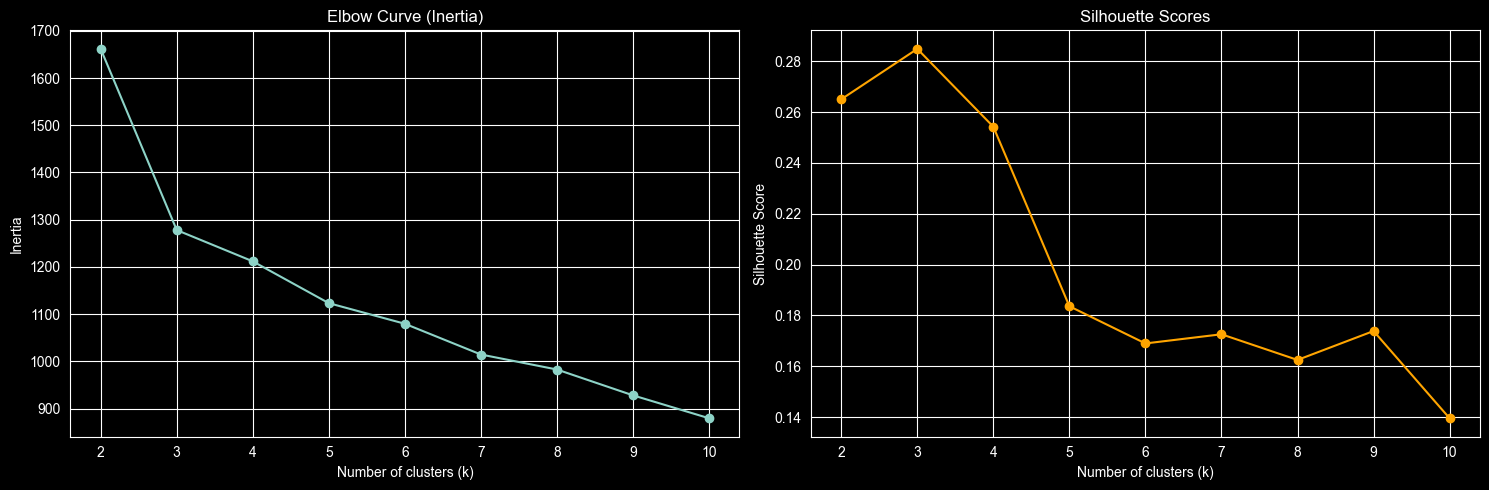

In [20]:
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(wine_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(wine_scaled, kmeans.labels_))

# Plotting the elbow curve and silhouette scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(k_range, inertia, marker='o')
ax1.set_title('Elbow Curve (Inertia)')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')

ax2.plot(k_range, silhouette_scores, marker='o', color='orange')
ax2.set_title('Silhouette Scores')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

### 3. Choosing the Optimal k

Based on the elbow curve, the "elbow" seems to be at k=3. The silhouette score also peaks at k=3, which confirms that 3 is the optimal number of clusters for this dataset. This aligns with the fact that the Wine dataset has 3 known cultivars.

### 4. Final K-Means Model and PCA Visualization

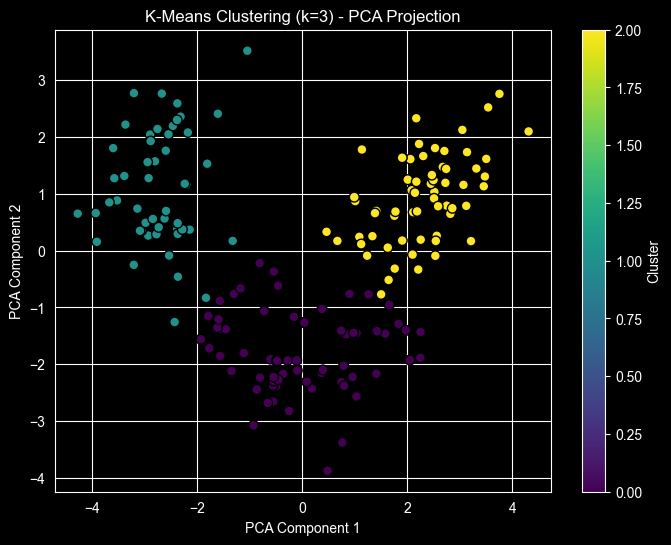

In [21]:
# Fit final K-Means model with k=3
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
kmeans_labels = kmeans_final.fit_predict(wine_scaled)

# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
wine_pca = pca.fit_transform(wine_scaled)

# Plot the clusters
plt.figure(figsize=(8, 6))
plt.scatter(wine_pca[:, 0], wine_pca[:, 1], c=kmeans_labels, cmap='viridis', edgecolors='k', s=50)
plt.title(f'K-Means Clustering (k={optimal_k}) - PCA Projection')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()

## Task 2: Hierarchical & Density-Based Clustering

### 1. Agglomerative Clustering

In [22]:
# Agglomerative Clustering with k=3
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k)
agg_labels = agg_clustering.fit_predict(wine_scaled)

### 2. Dendrogram

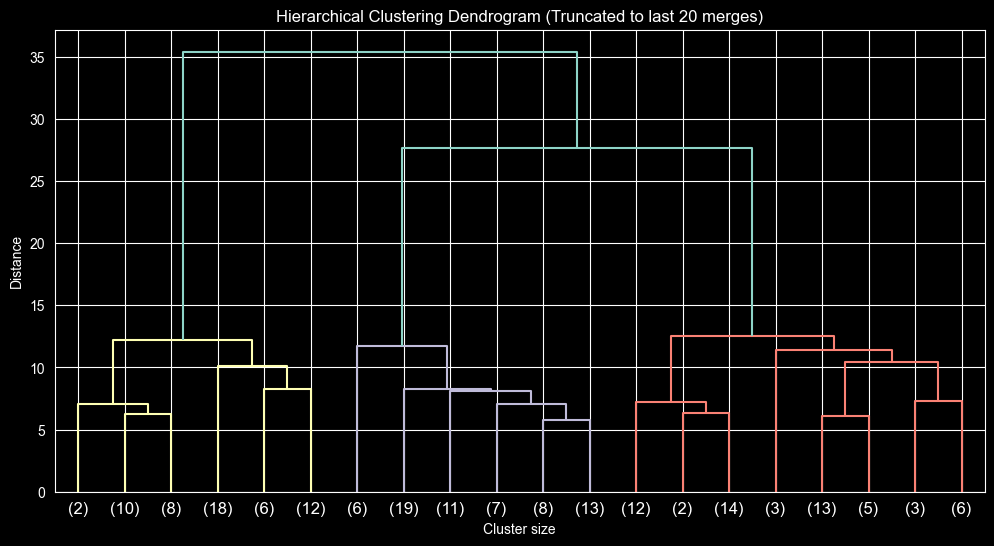

In [23]:
# Compute linkage matrix
linkage_matrix = linkage(wine_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=20)
plt.title('Hierarchical Clustering Dendrogram (Truncated to last 20 merges)')
plt.xlabel('Cluster size')
plt.ylabel('Distance')
plt.show()

### 3. DBSCAN Clustering

In [24]:
eps_values = [1.5, 2.0, 2.5, 3.0]
min_samples_values = [3, 4, 5, 6]
best_config = None
min_diff = float('inf')
results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(wine_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        results.append((eps, min_samples, n_clusters, n_noise))
        
        diff = abs(n_clusters - optimal_k)
        if diff < min_diff:
            min_diff = diff
            best_config = (eps, min_samples)
            best_n_clusters = n_clusters

for res in results:
    print(f"eps={res[0]}, min_samples={res[1]} -> Clusters: {res[2]}, Noise points: {res[3]}")

print(f"\nBest configuration (closest to k={optimal_k}): eps={best_config[0]}, min_samples={best_config[1]} with {best_n_clusters} clusters.")

eps=1.5, min_samples=3 -> Clusters: 8, Noise points: 147
eps=1.5, min_samples=4 -> Clusters: 2, Noise points: 169
eps=1.5, min_samples=5 -> Clusters: 0, Noise points: 178
eps=1.5, min_samples=6 -> Clusters: 0, Noise points: 178
eps=2.0, min_samples=3 -> Clusters: 5, Noise points: 64
eps=2.0, min_samples=4 -> Clusters: 6, Noise points: 66
eps=2.0, min_samples=5 -> Clusters: 5, Noise points: 85
eps=2.0, min_samples=6 -> Clusters: 3, Noise points: 100
eps=2.5, min_samples=3 -> Clusters: 1, Noise points: 23
eps=2.5, min_samples=4 -> Clusters: 1, Noise points: 23
eps=2.5, min_samples=5 -> Clusters: 1, Noise points: 24
eps=2.5, min_samples=6 -> Clusters: 1, Noise points: 26
eps=3.0, min_samples=3 -> Clusters: 2, Noise points: 7
eps=3.0, min_samples=4 -> Clusters: 1, Noise points: 11
eps=3.0, min_samples=5 -> Clusters: 1, Noise points: 11
eps=3.0, min_samples=6 -> Clusters: 1, Noise points: 11

Best configuration (closest to k=3): eps=2.0, min_samples=6 with 3 clusters.


### 4. Selecting Best DBSCAN Configuration

In [25]:
dbscan_best = DBSCAN(eps=best_config[0], min_samples=best_config[1])
dbscan_labels = dbscan_best.fit_predict(wine_scaled)

### 5. Compare Clustering Methods

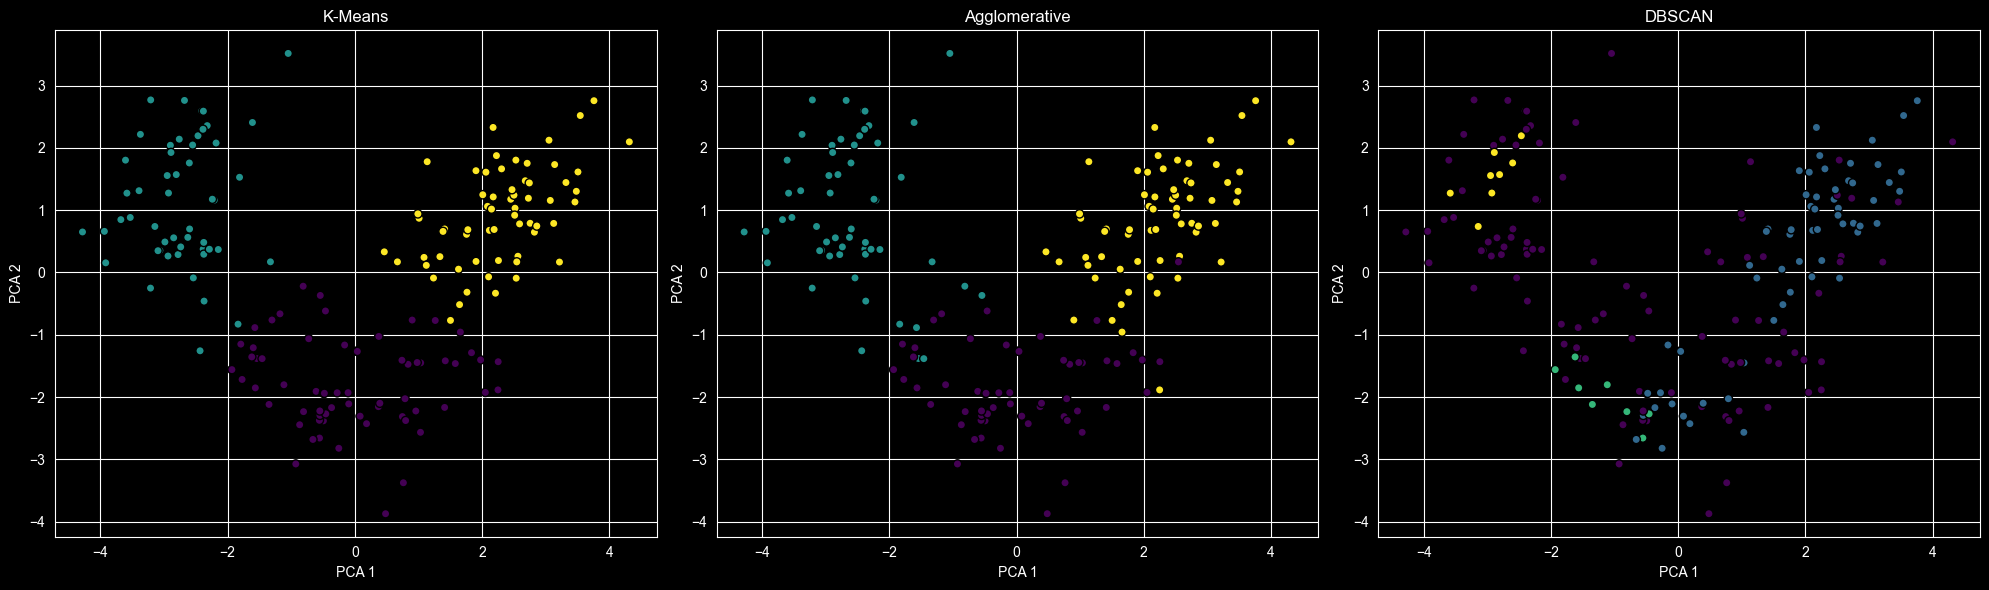

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].scatter(wine_pca[:, 0], wine_pca[:, 1], c=kmeans_labels, cmap='viridis', edgecolors='k')
axes[0].set_title('K-Means')

axes[1].scatter(wine_pca[:, 0], wine_pca[:, 1], c=agg_labels, cmap='viridis', edgecolors='k')
axes[1].set_title('Agglomerative')

axes[2].scatter(wine_pca[:, 0], wine_pca[:, 1], c=dbscan_labels, cmap='viridis', edgecolors='k')
axes[2].set_title('DBSCAN')

for ax in axes:
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')

plt.tight_layout()
plt.show()

### 6. Comparison of Approaches

Based on the visualization and hyperparameter tuning, we observe distinct behaviors across the three algorithms:

* **K-Means & Agglomerative:** Both produced nearly identical, well-defined partitions. Since these are distance-based and were constrained to $k=3$, they effectively captured the primary "globular" structures within the Wine dataset's PCA projection.
* **DBSCAN:** This approach proved highly sensitive to density settings. While the tuned configuration (**$\epsilon=2.0, min\_samples=6$**) successfully identified 3 clusters, it labeled **100 points as noise**.
* **Conclusion:** For this specific dataset, **K-Means** provides the most coherent and practical grouping. DBSCAN's high noise count suggests that the Wine dataset has relatively low density or high overlap in its feature space, making it difficult for density-based methods to "connect" points into larger, meaningful clusters without capturing excessive noise.

## Task 3: Dimensionality Reduction Comparison

### 1. Load and Prepare Palmer Penguins Dataset

In [27]:
# Load penguins dataset
penguins = sns.load_dataset("penguins")
penguins.dropna(inplace=True)

# Select numeric columns
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X_penguins = penguins[numeric_cols]
y_penguins = penguins['species']

# Scale the features
X_penguins_scaled = scaler.fit_transform(X_penguins)

### 2. Apply PCA, t-SNE, and MDS

In [28]:
# PCA
pca_penguins = PCA(n_components=2)
X_pca = pca_penguins.fit_transform(X_penguins_scaled)

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_penguins_scaled)

# MDS
mds = MDS(n_components=2, random_state=42)
X_mds = mds.fit_transform(X_penguins_scaled)

C:\Users\TEXNO\PycharmProjects\Ironhack\.venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
C:\Users\TEXNO\PycharmProjects\Ironhack\.venv\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


### 3. Visualize Dimensionality Reduction

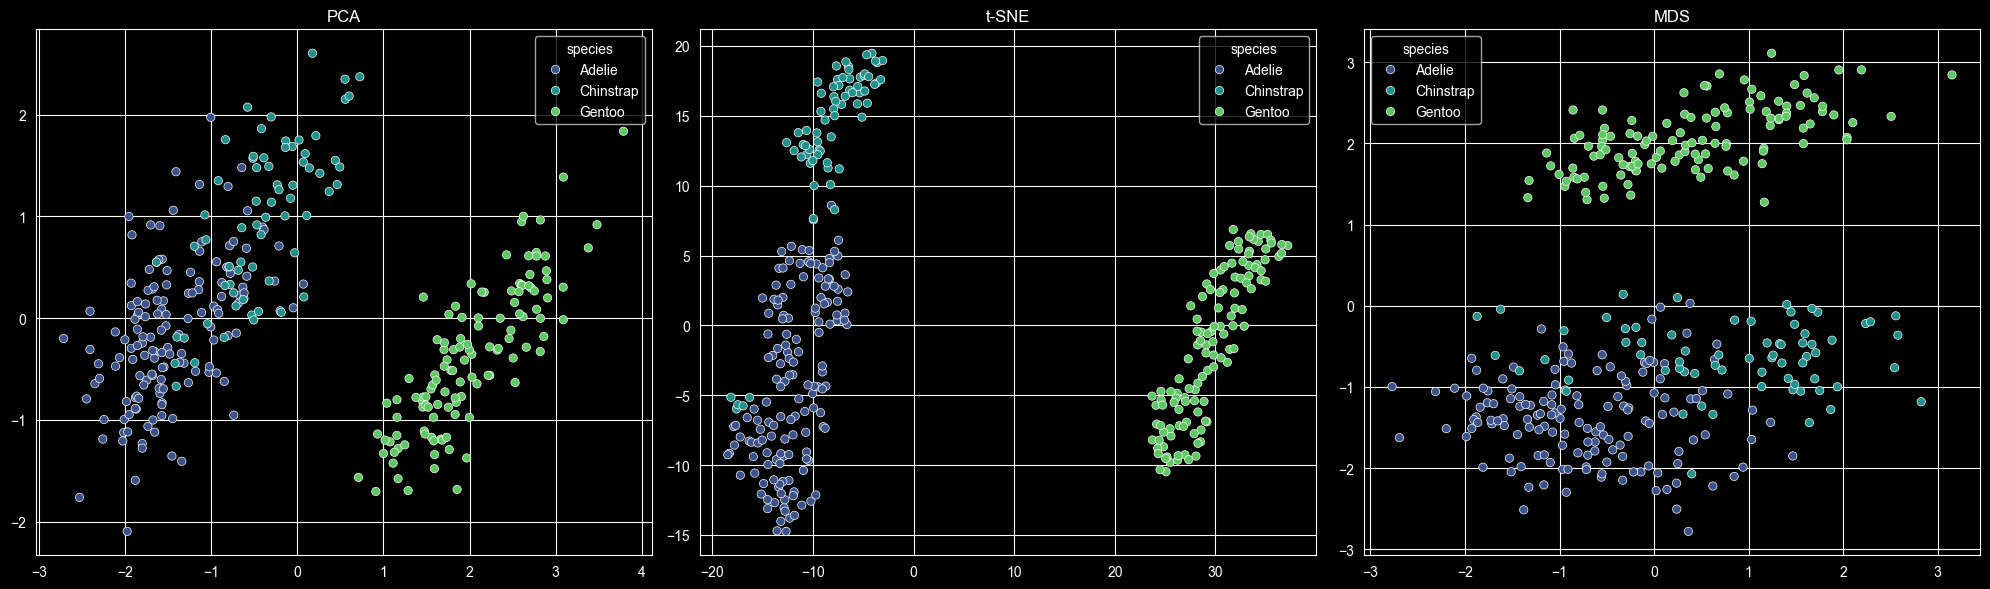

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_penguins, palette='viridis', ax=axes[0])
axes[0].set_title('PCA')

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_penguins, palette='viridis', ax=axes[1])
axes[1].set_title('t-SNE')

sns.scatterplot(x=X_mds[:, 0], y=X_mds[:, 1], hue=y_penguins, palette='viridis', ax=axes[2])
axes[2].set_title('MDS')

plt.tight_layout()
plt.show()

### 4. Discussion

t-SNE seems to provide the best visual separation between the three species, especially in creating distinct clusters. PCA also shows clear separation but with more overlap between Chinstrap and Adelie. MDS shows similar patterns to PCA. t-SNE can distort inter-cluster distances because it prioritizes local structure. It might give different results on repeated runs if the random seed is not fixed, due to its stochastic nature.

## Task 4: Putting It Together

### 1. K-Means on Penguins Data

In [30]:
# K-Means with k=3
kmeans_penguins = KMeans(n_clusters=3, random_state=42, n_init='auto')
penguins_clusters = kmeans_penguins.fit_predict(X_penguins_scaled)

### 2. Evaluation Scores

In [31]:
ari = adjusted_rand_score(y_penguins, penguins_clusters)
nmi = normalized_mutual_info_score(y_penguins, penguins_clusters)

print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Normalized Mutual Information: {nmi:.4f}")

Adjusted Rand Index: 0.7994
Normalized Mutual Information: 0.7899


### 3. Visualize K-Means vs True Labels

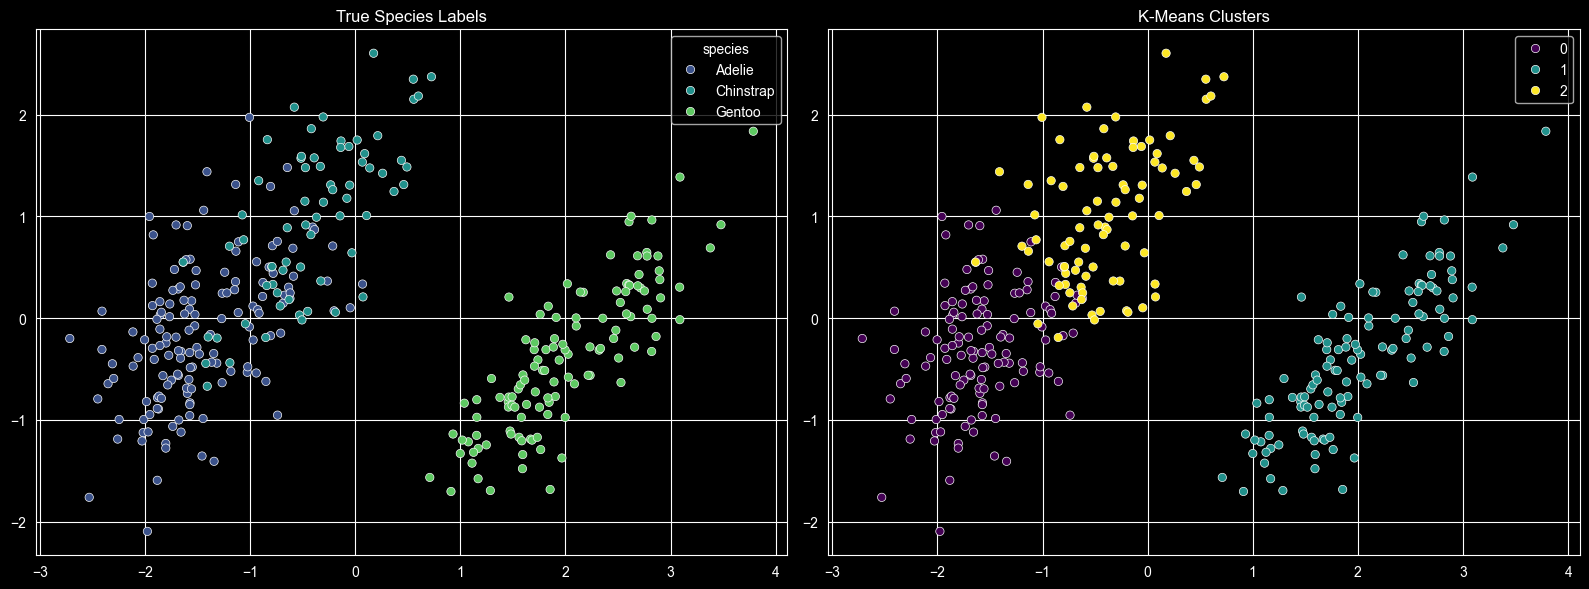

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_penguins, palette='viridis', ax=axes[0])
axes[0].set_title('True Species Labels')

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=penguins_clusters, palette='viridis', ax=axes[1])
axes[1].set_title('K-Means Clusters')

plt.tight_layout()
plt.show()

### 4. Interpretation

The unsupervised learning algorithm was able to "rediscover" the species to a large extent, as indicated by the ARI and NMI scores. It succeeded in separating Gentoo penguins clearly, but struggled somewhat with the overlap between Adelie and Chinstrap species. This suggests that while unsupervised methods are powerful for finding hidden structures, they might not perfectly align with human-defined labels when the underlying distributions overlap significantly.